<a href="https://colab.research.google.com/github/Deepu9981/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/Preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!kaggle datasets download -d raphfritzy/fitabase-data-4-12-16-5-12-16


Dataset URL: https://www.kaggle.com/datasets/raphfritzy/fitabase-data-4-12-16-5-12-16
License(s): CC0-1.0
fitabase-data-4-12-16-5-12-16.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
!unzip fitabase-data-4-12-16-5-12-16.zip



Archive:  fitabase-data-4-12-16-5-12-16.zip
replace Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/dailyCalories_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/dailyIntensities_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/dailySteps_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/heartrate_seconds_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/hourlyIntensities_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/minuteCaloriesNarrow_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/minuteCaloriesWide_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/minuteIntensitiesNarrow_merged.csv  
  inflating: Fitabase Data 4.12.16-5.12.16/minuteInte

In [4]:
import warnings
warnings.filterwarnings('ignore')


In [5]:
import pandas as pd
import numpy as np
print("Pandas library imported.")

Pandas library imported.


In [6]:
daily_steps_df = pd.read_csv('Fitabase Data 4.12.16-5.12.16/dailySteps_merged.csv')
daily_steps_df['ActivityDay'] = pd.to_datetime(daily_steps_df['ActivityDay'])
daily_steps_df['ActivityDate'] = daily_steps_df['ActivityDay'].dt.date
print("daily_steps_df loaded and processed.")

heartrate_seconds_df = pd.read_csv('Fitabase Data 4.12.16-5.12.16/heartrate_seconds_merged.csv')
heartrate_seconds_df['Time'] = pd.to_datetime(heartrate_seconds_df['Time'])
heartrate_seconds_df['ActivityDate'] = heartrate_seconds_df['Time'].dt.date
print("heartrate_seconds_df loaded and processed.")

hourly_steps_df = pd.read_csv('Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv')
hourly_steps_df['ActivityHour'] = pd.to_datetime(hourly_steps_df['ActivityHour'])
hourly_steps_df['ActivityDate'] = hourly_steps_df['ActivityHour'].dt.date
print("hourly_steps_df loaded and processed.")

minute_sleep_df = pd.read_csv('Fitabase Data 4.12.16-5.12.16/minuteSleep_merged.csv')
minute_sleep_df['date'] = pd.to_datetime(minute_sleep_df['date'])
minute_sleep_df['ActivityDate'] = minute_sleep_df['date'].dt.date
print("minute_sleep_df loaded and processed.")

sleep_day_df = pd.read_csv('Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv')
sleep_day_df['SleepDay'] = pd.to_datetime(sleep_day_df['SleepDay'])
sleep_day_df['ActivityDate'] = sleep_day_df['SleepDay'].dt.date
print("sleep_day_df loaded and processed.")

daily_steps_df loaded and processed.
heartrate_seconds_df loaded and processed.
hourly_steps_df loaded and processed.
minute_sleep_df loaded and processed.
sleep_day_df loaded and processed.


In [7]:
daily_avg_heartrate_df = heartrate_seconds_df.groupby(['Id', 'ActivityDate'])['Value'].mean().reset_index()
daily_avg_heartrate_df = daily_avg_heartrate_df.rename(columns={'Value': 'AvgDailyHeartRate'})
print("daily_avg_heartrate_df created.")

daily_total_steps_from_hourly_df = hourly_steps_df.groupby(['Id', 'ActivityDate'])['StepTotal'].sum().reset_index()
daily_total_steps_from_hourly_df = daily_total_steps_from_hourly_df.rename(columns={'StepTotal': 'TotalDailyStepsFromHourly'})
print("daily_total_steps_from_hourly_df created.")

minute_sleep_df['MinutesAsleep'] = minute_sleep_df['value'].apply(lambda x: 1 if x == 2 else 0)
minute_sleep_df['MinutesInBed'] = minute_sleep_df['value'].apply(lambda x: 1 if x in [1, 2, 3] else 0)
daily_sleep_from_minute_df = minute_sleep_df.groupby(['Id', 'ActivityDate'])[['MinutesAsleep', 'MinutesInBed']].sum().reset_index()
daily_sleep_from_minute_df = daily_sleep_from_minute_df.rename(columns={'MinutesAsleep': 'TotalMinutesAsleepFromMinute', 'MinutesInBed': 'TotalTimeInBedFromMinute'})
print("daily_sleep_from_minute_df created.")

daily_avg_heartrate_df created.
daily_total_steps_from_hourly_df created.
daily_sleep_from_minute_df created.


# **Merged Data**


In [8]:
merged_df = pd.merge(daily_steps_df, daily_avg_heartrate_df, on=['Id', 'ActivityDate'], how='outer')
print("Merged daily_steps_df with daily_avg_heartrate_df.")

merged_df = pd.merge(merged_df, daily_total_steps_from_hourly_df, on=['Id', 'ActivityDate'], how='outer')
print("Merged with daily_total_steps_from_hourly_df.")

merged_df = pd.merge(merged_df, daily_sleep_from_minute_df, on=['Id', 'ActivityDate'], how='outer')
print("Merged with daily_sleep_from_minute_df.")

merged_df = pd.merge(merged_df, sleep_day_df, on=['Id', 'ActivityDate'], how='outer')
print("Merged with sleep_day_df.")

Merged daily_steps_df with daily_avg_heartrate_df.
Merged with daily_total_steps_from_hourly_df.
Merged with daily_sleep_from_minute_df.
Merged with sleep_day_df.


In [9]:
print("Shape of the final merged DataFrame:", merged_df.shape)


Shape of the final merged DataFrame: (951, 12)


In [10]:
print("First 5 rows of the merged DataFrame:\n")
(merged_df.head())





First 5 rows of the merged DataFrame:



,Id,ActivityDay,StepTotal,ActivityDate,AvgDailyHeartRate,TotalDailyStepsFromHourly,TotalMinutesAsleepFromMinute,TotalTimeInBedFromMinute,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162.0,2016-04-12,NaN,13158.0,13.0,346.0,2016-04-12,1.0,327.0,346.0
1,1503960366,2016-04-13,10735.0,2016-04-13,NaN,10735.0,11.0,407.0,2016-04-13,2.0,384.0,407.0
2,1503960366,2016-04-14,10460.0,2016-04-14,NaN,10460.0,NaN,NaN,NaT,NaN,NaN,NaN
3,1503960366,2016-04-15,9762.0,2016-04-15,NaN,9685.0,22.0,442.0,2016-04-15,1.0,412.0,442.0
4,1503960366,2016-04-16,12669.0,2016-04-16,NaN,12669.0,20.0,400.0,2016-04-16,2.0,340.0,367.0


In [11]:
print("\nData types and non-null counts of the merged DataFrame:\n")
merged_df.info()


Data types and non-null counts of the merged DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Id                            951 non-null    int64         
 1   ActivityDay                   943 non-null    datetime64[ns]
 2   StepTotal                     943 non-null    float64       
 3   ActivityDate                  951 non-null    object        
 4   AvgDailyHeartRate             335 non-null    float64       
 5   TotalDailyStepsFromHourly     937 non-null    float64       
 6   TotalMinutesAsleepFromMinute  452 non-null    float64       
 7   TotalTimeInBedFromMinute      452 non-null    float64       
 8   SleepDay                      413 non-null    datetime64[ns]
 9   TotalSleepRecords             413 non-null    float64       
 10  TotalMinutesAsleep            413 non-nu

In [12]:
median_heartrate = merged_df['AvgDailyHeartRate'].median()
merged_df['AvgDailyHeartRate'].fillna(median_heartrate, inplace=True)
print("NaN values in 'AvgDailyHeartRate' column filled with median:", median_heartrate)


NaN values in 'AvgDailyHeartRate' column filled with median: 77.43914274160939


In [13]:
print("Updated info for merged_df after filling NaN values in AvgDailyHeartRate:")
merged_df.info()

Updated info for merged_df after filling NaN values in AvgDailyHeartRate:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Id                            951 non-null    int64         
 1   ActivityDay                   943 non-null    datetime64[ns]
 2   StepTotal                     943 non-null    float64       
 3   ActivityDate                  951 non-null    object        
 4   AvgDailyHeartRate             951 non-null    float64       
 5   TotalDailyStepsFromHourly     937 non-null    float64       
 6   TotalMinutesAsleepFromMinute  452 non-null    float64       
 7   TotalTimeInBedFromMinute      452 non-null    float64       
 8   SleepDay                      413 non-null    datetime64[ns]
 9   TotalSleepRecords             413 non-null    float64       
 10  TotalMinutesAsleep      

In [14]:
print("\nDescriptive statistics of the merged DataFrame:\n")
(merged_df.describe())


Descriptive statistics of the merged DataFrame:



,Id,ActivityDay,StepTotal,AvgDailyHeartRate,TotalDailyStepsFromHourly,TotalMinutesAsleepFromMinute,TotalTimeInBedFromMinute,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,9.510000e+02,943,943.000000,951.000000,937.000000,452.000000,452.000000,413,413.000000,413.000000,413.000000
mean,4.858913e+09,2016-04-26 07:21:18.897136896,7652.188759,77.834541,7589.897545,31.165929,420.429204,2016-04-26 12:40:05.811137792,1.118644,419.467312,458.639225
min,1.503960e+09,2016-04-12 00:00:00,0.000000,59.377175,0.000000,0.000000,4.000000,2016-04-12 00:00:00,1.000000,58.000000,61.000000
25%,2.320127e+09,2016-04-19 00:00:00,3795.000000,77.439143,3728.000000,11.000000,367.000000,2016-04-19 00:00:00,1.000000,361.000000,403.000000
50%,4.445115e+09,2016-04-26 00:00:00,7439.000000,77.439143,7379.000000,20.000000,442.500000,2016-04-27 00:00:00,1.000000,433.000000,463.000000
75%,6.962181e+09,2016-05-04 00:00:00,10734.000000,77.439143,10694.000000,31.000000,510.000000,2016-05-04 00:00:00,1.000000,490.000000,526.000000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,109.789625,36019.000000,227.000000,1038.000000,2016-05-12 00:00:00,3.000000,796.000000,961.000000
std,2.421256e+09,NaN,5086.532832,6.332105,5099.813692,39.684358,157.470813,NaN,0.345521,118.344679,127.101607


In [15]:
merged_df = merged_df.dropna()
print("Shape of merged_df after dropping NaN values:", merged_df.shape)

Shape of merged_df after dropping NaN values: (413, 12)


In [16]:
print("Updated info for merged_df after dropping NaN values:")
merged_df.info()

Updated info for merged_df after dropping NaN values:
<class 'pandas.core.frame.DataFrame'>
Index: 413 entries, 0 to 913
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Id                            413 non-null    int64         
 1   ActivityDay                   413 non-null    datetime64[ns]
 2   StepTotal                     413 non-null    float64       
 3   ActivityDate                  413 non-null    object        
 4   AvgDailyHeartRate             413 non-null    float64       
 5   TotalDailyStepsFromHourly     413 non-null    float64       
 6   TotalMinutesAsleepFromMinute  413 non-null    float64       
 7   TotalTimeInBedFromMinute      413 non-null    float64       
 8   SleepDay                      413 non-null    datetime64[ns]
 9   TotalSleepRecords             413 non-null    float64       
 10  TotalMinutesAsleep            413 non-null    flo

In [17]:
merged_df.isnull().sum()

,0
Id,0
ActivityDay,0
StepTotal,0
ActivityDate,0
AvgDailyHeartRate,0
TotalDailyStepsFromHourly,0
TotalMinutesAsleepFromMinute,0
TotalTimeInBedFromMinute,0
SleepDay,0
TotalSleepRecords,0


In [18]:
merged_df.head()

,Id,ActivityDay,StepTotal,ActivityDate,AvgDailyHeartRate,TotalDailyStepsFromHourly,TotalMinutesAsleepFromMinute,TotalTimeInBedFromMinute,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162.0,2016-04-12,77.439143,13158.0,13.0,346.0,2016-04-12,1.0,327.0,346.0
1,1503960366,2016-04-13,10735.0,2016-04-13,77.439143,10735.0,11.0,407.0,2016-04-13,2.0,384.0,407.0
3,1503960366,2016-04-15,9762.0,2016-04-15,77.439143,9685.0,22.0,442.0,2016-04-15,1.0,412.0,442.0
4,1503960366,2016-04-16,12669.0,2016-04-16,77.439143,12669.0,20.0,400.0,2016-04-16,2.0,340.0,367.0
5,1503960366,2016-04-17,9705.0,2016-04-17,77.439143,9705.0,11.0,679.0,2016-04-17,1.0,700.0,712.0


In [19]:
merged_df = merged_df.drop( merged_df.columns[[-4, -9]],axis=1)



In [20]:
merged_df.head()

,Id,ActivityDay,StepTotal,AvgDailyHeartRate,TotalDailyStepsFromHourly,TotalMinutesAsleepFromMinute,TotalTimeInBedFromMinute,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162.0,77.439143,13158.0,13.0,346.0,1.0,327.0,346.0
1,1503960366,2016-04-13,10735.0,77.439143,10735.0,11.0,407.0,2.0,384.0,407.0
3,1503960366,2016-04-15,9762.0,77.439143,9685.0,22.0,442.0,1.0,412.0,442.0
4,1503960366,2016-04-16,12669.0,77.439143,12669.0,20.0,400.0,2.0,340.0,367.0
5,1503960366,2016-04-17,9705.0,77.439143,9705.0,11.0,679.0,1.0,700.0,712.0


In [21]:
heart_rate = merged_df["AvgDailyHeartRate"]
np.var(heart_rate)

33.765600467586474

In [22]:
np.std(heart_rate)

5.810817538658951

In [23]:
np.corrcoef(merged_df["AvgDailyHeartRate"], merged_df["StepTotal"])

array([[1.        , 0.09674521],
       [0.09674521, 1.        ]])

In [24]:
np.cov(merged_df["AvgDailyHeartRate"], merged_df["StepTotal"])

array([[3.38475558e+01, 2.33972873e+03],
       [2.33972873e+03, 1.72800420e+07]])

In [25]:
cov_matrix = merged_df.cov(numeric_only=True)
cov_matrix

,Id,StepTotal,AvgDailyHeartRate,TotalDailyStepsFromHourly,TotalMinutesAsleepFromMinute,TotalTimeInBedFromMinute,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
Id,4.245084e+18,9.717057e+10,-8.014339e+08,6.596105e+10,-1.348397e+10,1.453643e+10,-8.935827e+06,1.953514e+10,5.529815e+08
StepTotal,9.717057e+10,1.728004e+07,2.339729e+03,1.707571e+07,1.621189e+04,-7.748838e+04,-2.333856e+02,-9.192901e+04,-8.668129e+04
AvgDailyHeartRate,-8.014339e+08,2.339729e+03,3.384756e+01,2.219289e+03,8.580649e-02,-1.259392e+02,-1.622876e-01,-1.200030e+02,-1.170823e+02
TotalDailyStepsFromHourly,6.596105e+10,1.707571e+07,2.219289e+03,1.718392e+07,1.655936e+04,-7.622936e+04,-2.271988e+02,-9.141795e+04,-8.580267e+04
TotalMinutesAsleepFromMinute,-1.348397e+10,1.621189e+04,8.580649e-02,1.655936e+04,1.613583e+03,1.363371e+03,1.050930e+00,-5.600796e+02,1.102902e+03
TotalTimeInBedFromMinute,1.453643e+10,-7.748838e+04,-1.259392e+02,-7.622936e+04,1.363371e+03,1.639823e+04,8.806648e+00,1.248608e+04,1.425799e+04
TotalSleepRecords,-8.935827e+06,-2.333856e+02,-1.622876e-01,-2.271988e+02,1.050930e+00,8.806648e+00,1.193846e-01,6.784227e+00,7.593879e+00
TotalMinutesAsleep,1.953514e+10,-9.192901e+04,-1.200030e+02,-9.141795e+04,-5.600796e+02,1.248608e+04,6.784227e+00,1.400546e+04,1.399575e+04
TotalTimeInBed,5.529815e+08,-8.668129e+04,-1.170823e+02,-8.580267e+04,1.102902e+03,1.425799e+04,7.593879e+00,1.399575e+04,1.615482e+04


# **Visualizes**

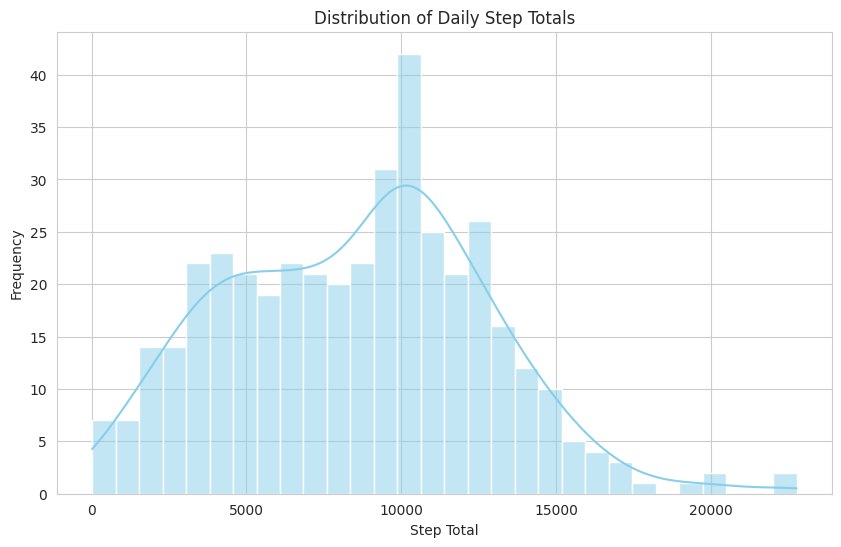

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# 1. Histogram for Daily StepTotal Distribution
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['StepTotal'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Daily Step Totals')
plt.xlabel('Step Total')
plt.ylabel('Frequency')
plt.show()


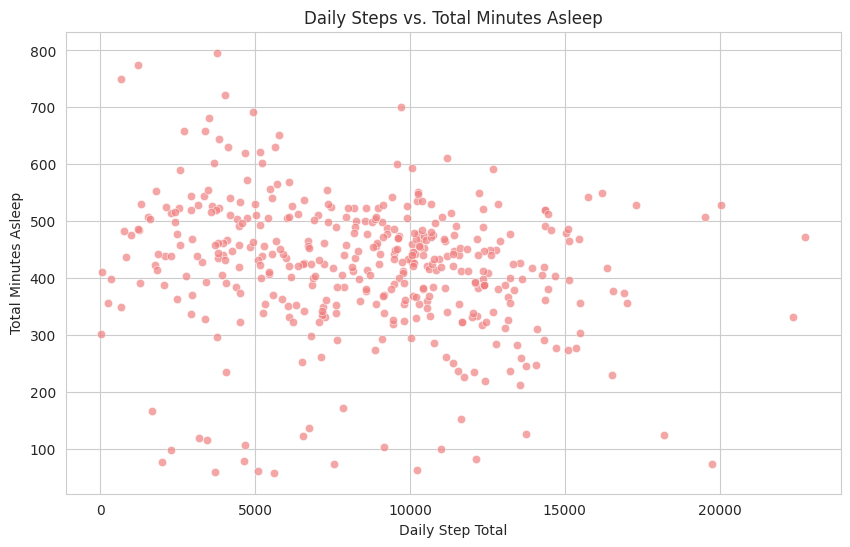

In [27]:
# 2. Scatter plot for StepTotal vs. TotalMinutesAsleep
plt.figure(figsize=(10, 6))
sns.scatterplot(x='StepTotal', y='TotalMinutesAsleep', data=merged_df, alpha=0.7, color='lightcoral')
plt.title('Daily Steps vs. Total Minutes Asleep')
plt.xlabel('Daily Step Total')
plt.ylabel('Total Minutes Asleep')
plt.show()


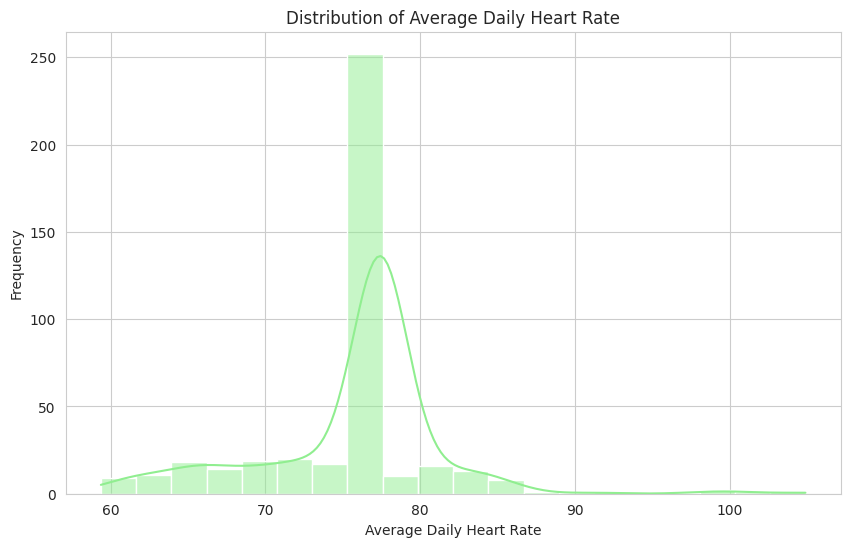

In [28]:
# 3. Histogram for Average Daily Heart Rate Distribution
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['AvgDailyHeartRate'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of Average Daily Heart Rate')
plt.xlabel('Average Daily Heart Rate')
plt.ylabel('Frequency')
plt.show()


In [29]:
merged_df.to_csv('merged_df.csv', index=False)
